# Spaceship Titanic — Ensemble Learning

**Bài tập về nhà buổi 11 — Ensemble Learning**

Mục tiêu: Dự đoán hành khách nào bị dịch chuyển sang chiều không gian khác trong vụ va chạm của tàu Spaceship Titanic.  
Áp dụng các kỹ thuật Ensemble Learning: **Bagging**, **Boosting**, **Stacking** và so sánh benchmark.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    StackingClassifier,
    ExtraTreesClassifier,
    VotingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## Import thư viện

Sử dụng các thư viện chính:
- **pandas / numpy**: xử lý dữ liệu
- **matplotlib / seaborn**: trực quan hóa
- **scikit-learn**: các mô hình ML cơ bản và Ensemble (Bagging, Boosting, Stacking, Voting)
- **XGBoost, LightGBM, CatBoost**: các thư viện Gradient Boosting hiệu năng cao

In [7]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (8693, 14)
Test shape:  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Load dữ liệu

- **train.csv**: ~8693 hành khách dùng để huấn luyện (có cột `Transported` là nhãn).
- **test.csv**: ~4277 hành khách cần dự đoán.
- **sample_submission.csv**: file mẫu để nộp lên Kaggle.

In [8]:
train.info()
print('\n--- Missing values (train) ---')
print(train.isnull().sum())
print(f'\n--- Missing values % ---')
print((train.isnull().sum() / len(train) * 100).round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB

--- Missing values (train) ---
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age       

In [9]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


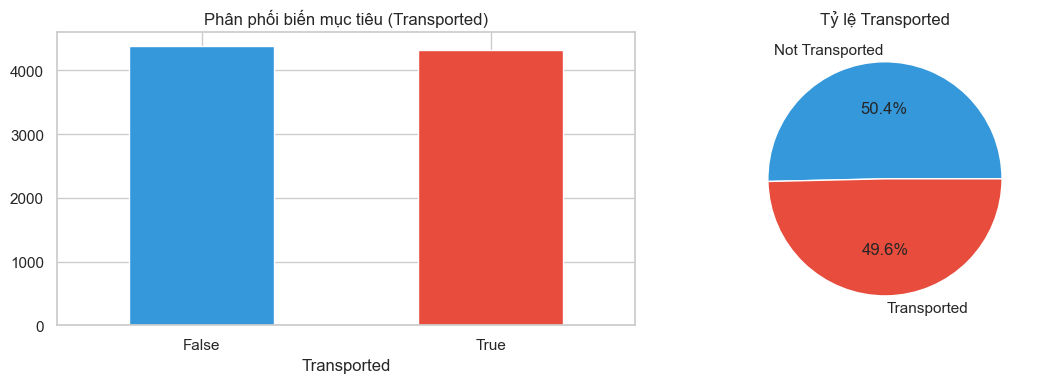

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['Transported'].value_counts().plot.bar(ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Phân phối biến mục tiêu (Transported)')
axes[0].set_xticklabels(['False', 'True'], rotation=0)

train['Transported'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=['#3498db', '#e74c3c'],
    labels=['Not Transported', 'Transported']
)
axes[1].set_ylabel('')
axes[1].set_title('Tỷ lệ Transported')

plt.tight_layout()
plt.show()

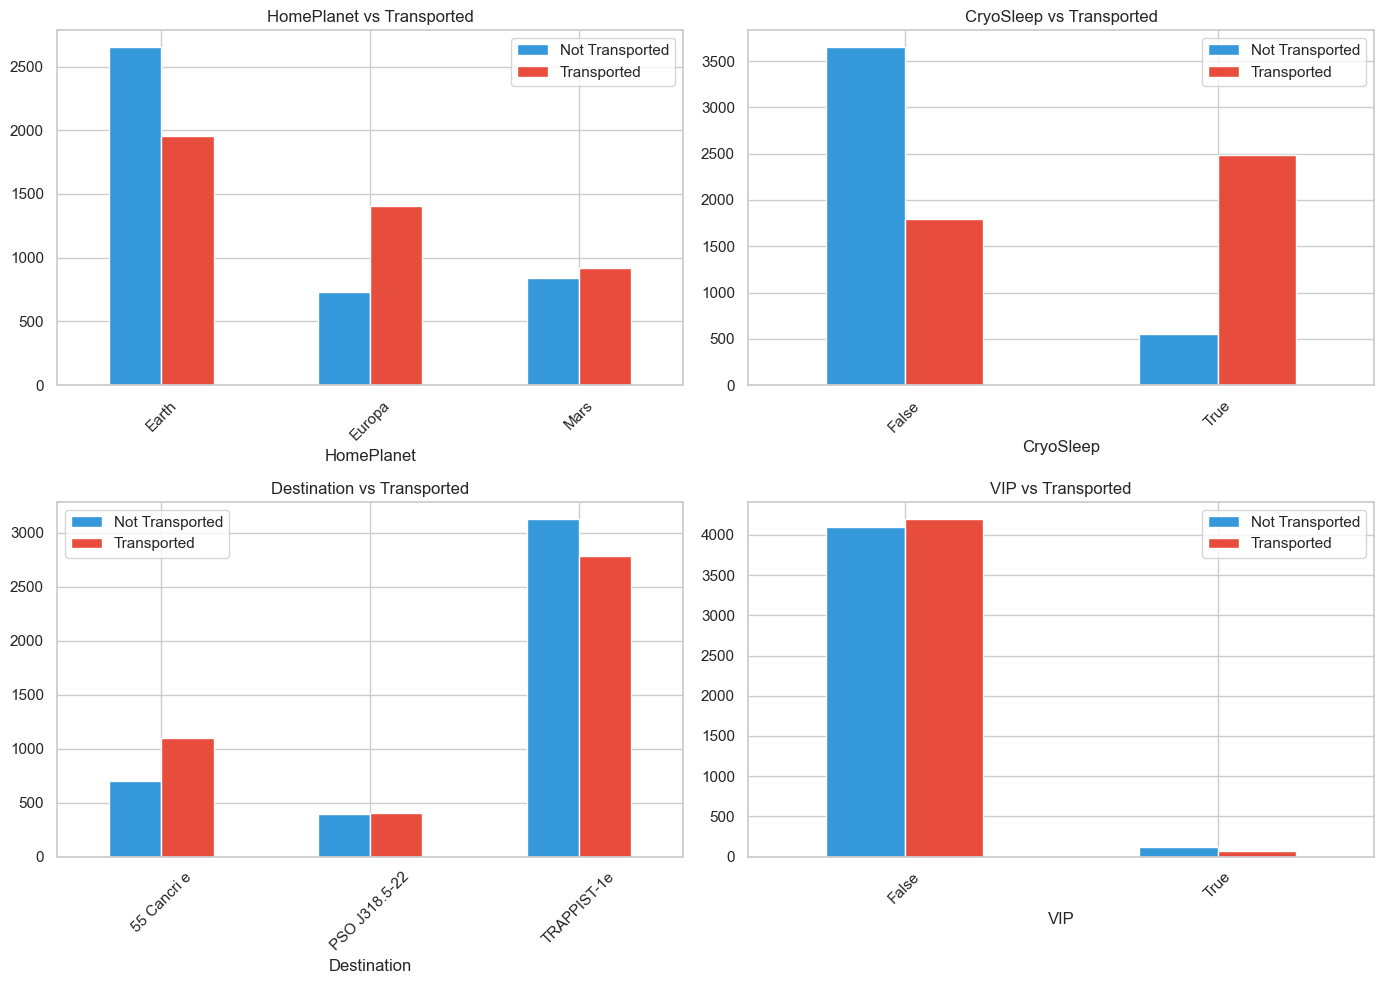

In [11]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), cat_cols):
    pd.crosstab(train[col], train['Transported']).plot.bar(ax=ax, color=['#3498db', '#e74c3c'])
    ax.set_title(f'{col} vs Transported')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.legend(['Not Transported', 'Transported'])

plt.tight_layout()
plt.show()

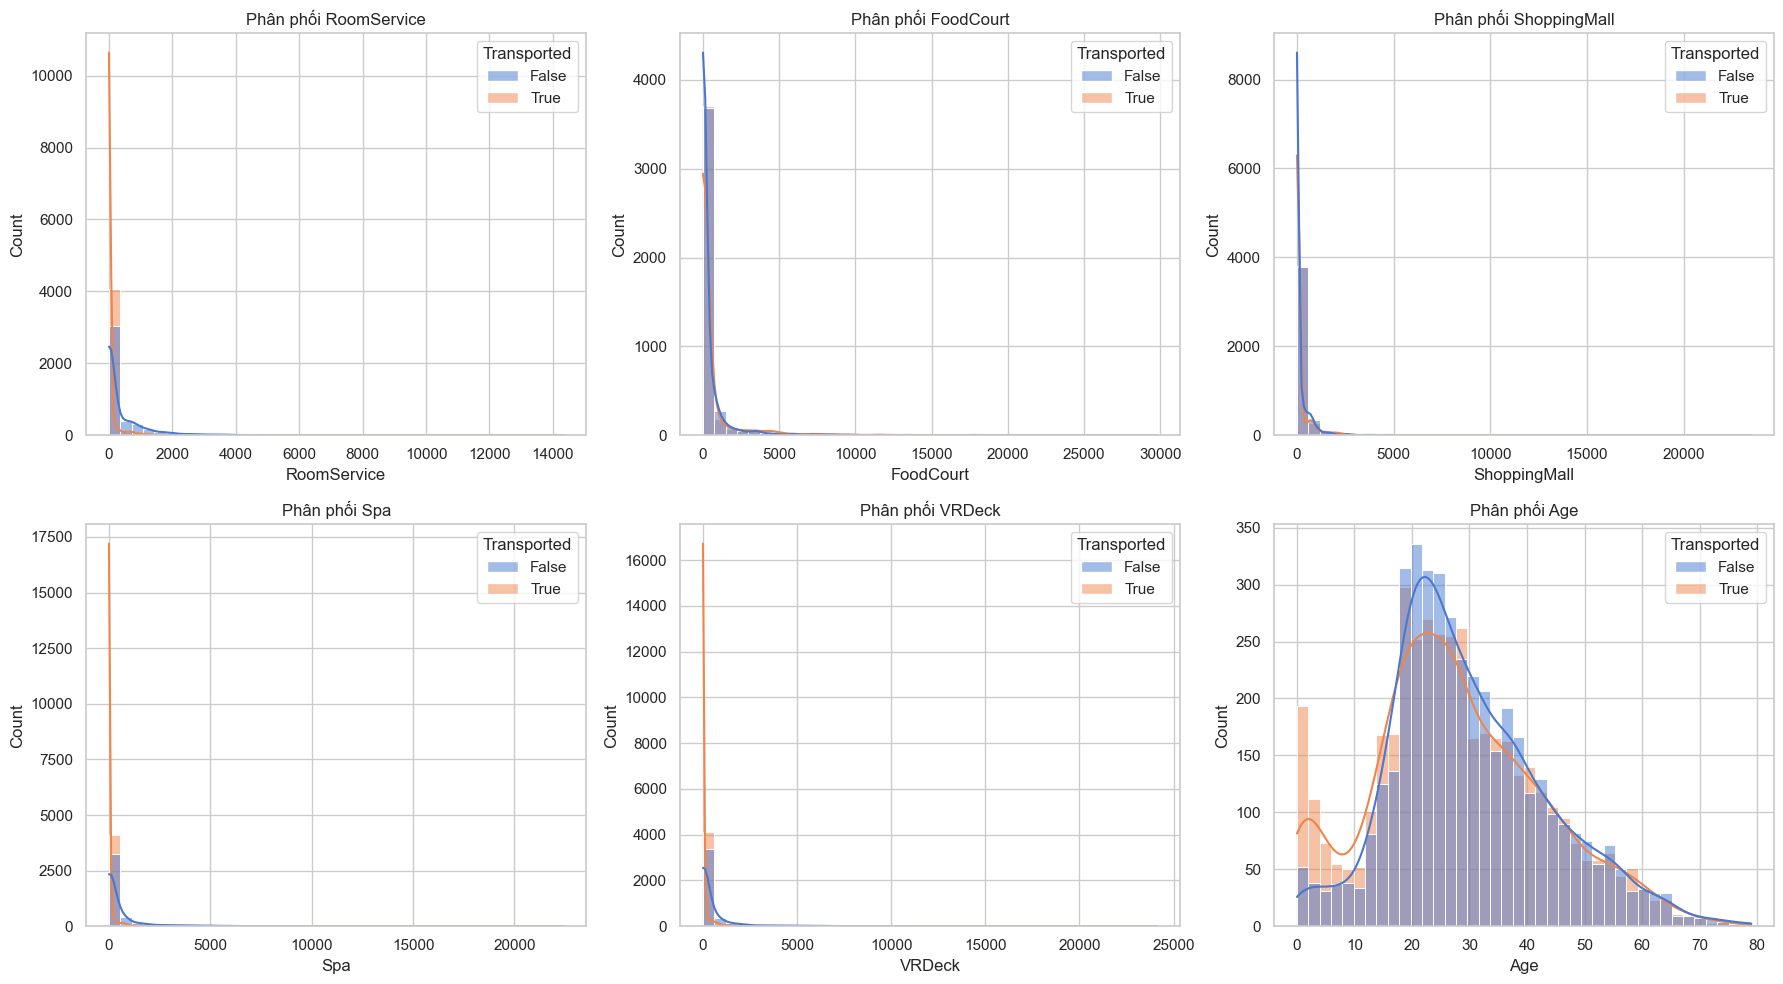

In [12]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), spend_cols + ['Age']):
    sns.histplot(data=train, x=col, hue='Transported', kde=True, ax=ax, bins=40)
    ax.set_title(f'Phân phối {col}')

plt.tight_layout()
plt.show()

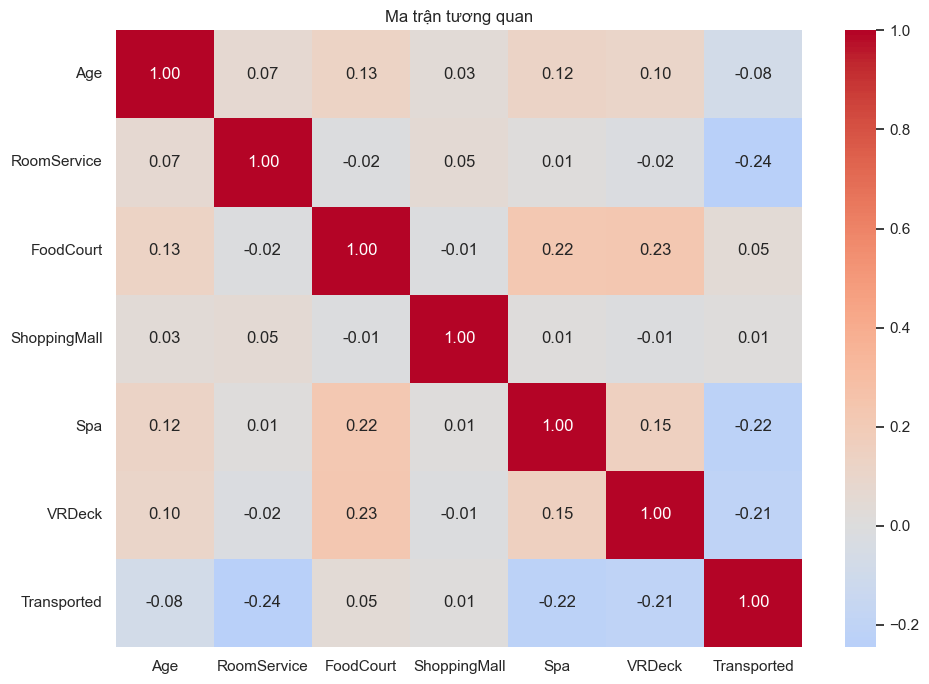

In [13]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
corr_df = train[num_cols + ['Transported']].copy()
corr_df['Transported'] = corr_df['Transported'].astype(int)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()

## Khám phá dữ liệu (EDA)

**Nhận xét chính:**
1. **Biến mục tiêu** (`Transported`) khá cân bằng (~50/50), không cần xử lý mất cân bằng lớp.
2. **Missing values**: Các cột đều có missing ở mức thấp (~2%). Cột `Cabin` và `Name` có thể trích xuất thêm đặc trưng.
3. **CryoSleep**: Hành khách ở chế độ ngủ đông có tỷ lệ bị transported cao hơn hẳn (~80%).
4. **Chi tiêu (Spending)**: Phân phối lệch phải rất mạnh. Hành khách chi tiêu ít/không chi tiêu có xu hướng bị transported nhiều hơn.
5. **HomePlanet**: Hành khách từ Europa có tỷ lệ transported cao nhất.
6. **Age**: Trẻ em (dưới 12 tuổi) có tỷ lệ transported cao.

In [14]:
combined = pd.concat([train, test], axis=0, ignore_index=True)
print(f'Combined shape: {combined.shape}')

combined['Group'] = combined['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
combined['GroupSize'] = combined.groupby('Group')['Group'].transform('count')
combined['IsAlone'] = (combined['GroupSize'] == 1).astype(int)

combined['Cabin_Deck'] = combined['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else np.nan)
combined['Cabin_Num'] = combined['Cabin'].apply(lambda x: int(x.split('/')[1]) if pd.notna(x) else np.nan)
combined['Cabin_Side'] = combined['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else np.nan)

combined['TotalSpend'] = combined[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
combined['NoSpend'] = (combined['TotalSpend'] == 0).astype(int)

combined['HasName'] = combined['Name'].notna().astype(int)
combined['Surname'] = combined['Name'].apply(lambda x: x.split(' ')[-1] if pd.notna(x) else 'Unknown')
combined['FamilySize'] = combined.groupby('Surname')['Surname'].transform('count')

combined['AgeBin'] = pd.cut(combined['Age'], bins=[0, 12, 18, 30, 50, 80], labels=[0, 1, 2, 3, 4])
combined['AgeBin'] = combined['AgeBin'].astype(float)

combined['SpendPerPerson'] = combined['TotalSpend'] / combined['GroupSize']

for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    combined[f'{col}_log'] = np.log1p(combined[col])

print('Các cột mới:', list(combined.columns))

Combined shape: (12970, 14)
Các cột mới: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported', 'Group', 'GroupSize', 'IsAlone', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side', 'TotalSpend', 'NoSpend', 'HasName', 'Surname', 'FamilySize', 'AgeBin', 'SpendPerPerson', 'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log']


## Feature Engineering

Trích xuất thêm các đặc trưng mới từ dữ liệu gốc:

| Đặc trưng mới | Nguồn gốc | Ý nghĩa |
|---|---|---|
| `Group`, `GroupSize`, `IsAlone` | `PassengerId` | Nhóm hành khách, kích thước nhóm, đi một mình? |
| `Cabin_Deck`, `Cabin_Num`, `Cabin_Side` | `Cabin` | Tầng, số phòng, bên Trái/Phải của tàu |
| `TotalSpend`, `NoSpend` | Các cột chi tiêu | Tổng chi tiêu, có chi tiêu hay không |
| `Surname`, `FamilySize` | `Name` | Họ, quy mô gia đình |
| `AgeBin` | `Age` | Nhóm tuổi (trẻ em, thiếu niên, thanh niên, trung niên, cao tuổi) |
| `SpendPerPerson` | `TotalSpend / GroupSize` | Chi tiêu trung bình/người trong nhóm |
| `*_log` | Các cột chi tiêu | Biến đổi log để giảm skewness |

In [15]:
num_fill = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'Cabin_Num', 'TotalSpend', 'SpendPerPerson', 'AgeBin', 'FamilySize',
            'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log']

for col in num_fill:
    combined[col] = combined[col].fillna(combined[col].median())

cat_fill = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side']
for col in cat_fill:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

combined['CryoSleep'] = combined['CryoSleep'].astype(bool).astype(int)
combined['VIP'] = combined['VIP'].astype(bool).astype(int)

label_encoders = {}
for col in ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    label_encoders[col] = le

drop_cols = ['PassengerId', 'Cabin', 'Name', 'Surname', 'Transported']
feature_cols = [c for c in combined.columns if c not in drop_cols]

train_processed = combined[:len(train)].copy()
test_processed = combined[len(train):].copy()

X = train_processed[feature_cols].values
y = train['Transported'].astype(int).values
X_test_final = test_processed[feature_cols].values

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test_final = scaler.transform(X_test_final)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

X_train: (6954, 27), X_val: (1739, 27)
Features (27): ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Group', 'GroupSize', 'IsAlone', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side', 'TotalSpend', 'NoSpend', 'HasName', 'FamilySize', 'AgeBin', 'SpendPerPerson', 'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log']


## Tiền xử lý dữ liệu

1. **Xử lý missing values**: Cột số → điền median, cột phân loại → điền mode.
2. **Mã hóa biến phân loại**: `LabelEncoder` cho `HomePlanet`, `Destination`, `Cabin_Deck`, `Cabin_Side`.
3. **Chuẩn hóa**: `StandardScaler` để đưa các đặc trưng về cùng thang đo (quan trọng cho Logistic Regression, SVM).
4. **Chia tập**: 80% train, 20% validation (stratified để giữ tỷ lệ lớp).

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
}

results = {}

for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = {'CV Mean': scores.mean(), 'CV Std': scores.std(), 'Val Acc': val_acc}
    print(f'{name:30s} | CV: {scores.mean():.4f} ± {scores.std():.4f} | Val: {val_acc:.4f}')

Logistic Regression            | CV: 0.7924 ± 0.0058 | Val: 0.7878
Decision Tree                  | CV: 0.7397 ± 0.0130 | Val: 0.7481


## Mô hình Baseline (không Ensemble)

Huấn luyện 2 mô hình cơ bản làm mốc so sánh:
- **Logistic Regression**: Mô hình tuyến tính, đơn giản, nhanh.
- **Decision Tree**: Mô hình cây quyết định đơn lẻ, dễ overfit.

Đánh giá bằng **5-Fold Stratified Cross-Validation** và **Validation Accuracy**.

In [17]:
bagging_models = {
    'Bagging (DT)': BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=200, max_samples=0.8, max_features=0.8,
        random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=500, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
}

for name, model in bagging_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = {'CV Mean': scores.mean(), 'CV Std': scores.std(), 'Val Acc': val_acc}
    print(f'{name:30s} | CV: {scores.mean():.4f} ± {scores.std():.4f} | Val: {val_acc:.4f}')

Bagging (DT)                   | CV: 0.7944 ± 0.0110 | Val: 0.7999
Random Forest                  | CV: 0.7974 ± 0.0056 | Val: 0.7987
Extra Trees                    | CV: 0.8030 ± 0.0074 | Val: 0.7959


## Bagging (Bootstrap Aggregating)

**Ý tưởng**: Tạo nhiều mô hình con (base learner) từ các tập con dữ liệu được lấy mẫu ngẫu nhiên có hoàn lại (bootstrap). Kết quả cuối cùng là **bình chọn đa số** (classification) hoặc **trung bình** (regression).

**Ưu điểm**:
- Giảm **variance** (phương sai) → giảm overfitting.
- Đặc biệt hiệu quả với các mô hình có variance cao (Decision Tree).
- Các base learner huấn luyện **song song** → nhanh.

**Các mô hình Bagging sử dụng**:
1. **BaggingClassifier**: Bagging tổng quát với Decision Tree làm base learner.
2. **Random Forest**: Bagging + random feature selection tại mỗi node split.
3. **Extra Trees**: Giống RF nhưng split point được chọn ngẫu nhiên → đa dạng hơn, nhanh hơn.

In [18]:
boosting_models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=300, learning_rate=0.05, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.05,
        random_state=42, verbose=0
    ),
}

for name, model in boosting_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = {'CV Mean': scores.mean(), 'CV Std': scores.std(), 'Val Acc': val_acc}
    print(f'{name:30s} | CV: {scores.mean():.4f} ± {scores.std():.4f} | Val: {val_acc:.4f}')

AdaBoost                       | CV: 0.7886 ± 0.0112 | Val: 0.7838
Gradient Boosting              | CV: 0.7998 ± 0.0041 | Val: 0.8097
XGBoost                        | CV: 0.8013 ± 0.0031 | Val: 0.8235
LightGBM                       | CV: 0.7991 ± 0.0034 | Val: 0.8177
CatBoost                       | CV: 0.8100 ± 0.0023 | Val: 0.8125


## Boosting

**Ý tưởng**: Huấn luyện các mô hình con **tuần tự**, mỗi mô hình sau tập trung sửa lỗi của mô hình trước. Kết quả cuối cùng là **tổng có trọng số** các mô hình con.

**Ưu điểm**:
- Giảm **bias** (độ lệch) → mô hình mạnh hơn.
- Thường cho kết quả tốt nhất trên dữ liệu dạng bảng (tabular data).

**Nhược điểm**:
- Huấn luyện **tuần tự** → chậm hơn Bagging.
- Dễ overfit nếu không tune hyperparameter cẩn thận.

**Các mô hình Boosting sử dụng**:

| Mô hình | Đặc điểm |
|---|---|
| **AdaBoost** | Boosting kinh điển, tăng trọng số mẫu bị phân loại sai |
| **Gradient Boosting** | Tối ưu hàm loss bằng gradient descent trên không gian hàm |
| **XGBoost** | GB cải tiến: regularization, histogram-based, parallel tree building |
| **LightGBM** | Leaf-wise growth, histogram-based → rất nhanh trên dữ liệu lớn |
| **CatBoost** | Xử lý tốt biến phân loại, Ordered Boosting chống overfitting |

In [19]:
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )),
    ('lgbm', LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )),
    ('cat', CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        random_state=42, verbose=0
    )),
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

scores = cross_val_score(stacking_model, X_train, y_train, cv=cv, scoring='accuracy')
stacking_model.fit(X_train, y_train)
val_acc = accuracy_score(y_val, stacking_model.predict(X_val))
results['Stacking'] = {'CV Mean': scores.mean(), 'CV Std': scores.std(), 'Val Acc': val_acc}
print(f'{"Stacking":30s} | CV: {scores.mean():.4f} ± {scores.std():.4f} | Val: {val_acc:.4f}')

Stacking                       | CV: 0.8100 ± 0.0052 | Val: 0.8033


## Stacking (Stacked Generalization)

**Ý tưởng**: Kết hợp dự đoán của nhiều mô hình khác loại (diverse base learners) bằng một **meta-learner** (mô hình bậc 2).

**Quy trình**:
1. **Level 0** (Base learners): Huấn luyện RF, ExtraTrees, XGBoost, LightGBM, CatBoost bằng cross-validation.
2. **Level 1** (Meta-learner): Logistic Regression nhận đầu vào là dự đoán (xác suất) của các base learners → đưa ra dự đoán cuối.

**Ưu điểm**:
- Khai thác điểm mạnh của nhiều loại mô hình khác nhau.
- Meta-learner học cách **cân bằng** và **bổ sung** giữa các base learners.
- Thường cho kết quả tốt hơn bất kỳ base learner đơn lẻ nào.

**Nhược điểm**:
- Tốn thời gian huấn luyện (base learners × K-fold CV).
- Phức tạp hơn trong triển khai.

In [20]:
voting_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, n_jobs=-1
        )),
        ('lgbm', LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbose=-1
        )),
        ('cat', CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.05,
            random_state=42, verbose=0
        )),
    ],
    voting='soft',
    n_jobs=-1
)

scores = cross_val_score(voting_model, X_train, y_train, cv=cv, scoring='accuracy')
voting_model.fit(X_train, y_train)
val_acc = accuracy_score(y_val, voting_model.predict(X_val))
results['Soft Voting'] = {'CV Mean': scores.mean(), 'CV Std': scores.std(), 'Val Acc': val_acc}
print(f'{"Soft Voting":30s} | CV: {scores.mean():.4f} ± {scores.std():.4f} | Val: {val_acc:.4f}')

Soft Voting                    | CV: 0.8053 ± 0.0048 | Val: 0.8108


## Voting Classifier

**Ý tưởng**: Kết hợp nhiều mô hình bằng **bỏ phiếu**.

- **Hard Voting**: Mỗi mô hình vote 1 nhãn, nhãn nào nhiều vote nhất thắng.
- **Soft Voting** (sử dụng ở đây): Trung bình xác suất dự đoán của các mô hình → chọn lớp có xác suất trung bình cao nhất.

Soft Voting thường tốt hơn Hard Voting vì nó tận dụng **thông tin xác suất** (confidence) từ mỗi mô hình.

In [21]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('CV Mean', ascending=False)
results_df.index.name = 'Model'
results_df.columns = ['CV Accuracy (Mean)', 'CV Accuracy (Std)', 'Validation Accuracy']
print('\n' + '='*80)
print('BẢNG SO SÁNH BENCHMARK CÁC MÔ HÌNH')
print('='*80)
print(results_df.to_string())


BẢNG SO SÁNH BENCHMARK CÁC MÔ HÌNH
                     CV Accuracy (Mean)  CV Accuracy (Std)  Validation Accuracy
Model                                                                          
Stacking                       0.810038           0.005242             0.803335
CatBoost                       0.810037           0.002299             0.812536
Soft Voting                    0.805293           0.004752             0.810811
Extra Trees                    0.802993           0.007416             0.795860
XGBoost                        0.801266           0.003082             0.823462
Gradient Boosting              0.799828           0.004091             0.809661
LightGBM                       0.799108           0.003378             0.817711
Random Forest                  0.797383           0.005551             0.798735
Bagging (DT)                   0.794365           0.010977             0.799885
Logistic Regression            0.792350           0.005830             0.787809
AdaB

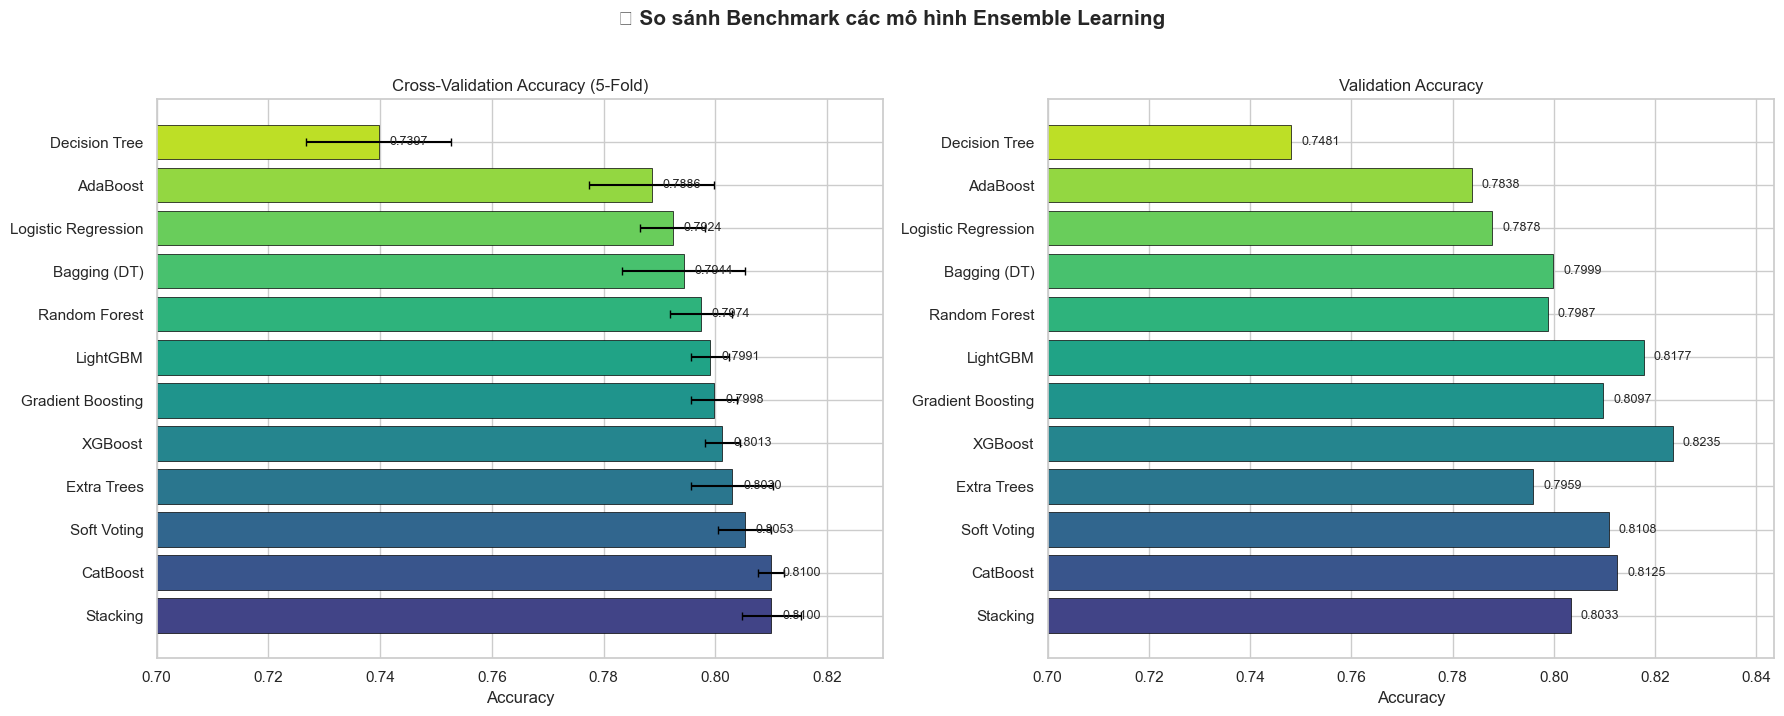

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_df)))

bars = axes[0].barh(results_df.index, results_df['CV Accuracy (Mean)'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].errorbar(
    results_df['CV Accuracy (Mean)'], results_df.index,
    xerr=results_df['CV Accuracy (Std)'], fmt='none', color='black', capsize=3
)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Cross-Validation Accuracy (5-Fold)')
axes[0].set_xlim(0.70, results_df['CV Accuracy (Mean)'].max() + 0.02)
for bar, val in zip(bars, results_df['CV Accuracy (Mean)']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

bars2 = axes[1].barh(results_df.index, results_df['Validation Accuracy'], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlim(0.70, results_df['Validation Accuracy'].max() + 0.02)
for bar, val in zip(bars2, results_df['Validation Accuracy']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('📊 So sánh Benchmark các mô hình Ensemble Learning', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## So sánh Benchmark

**Phân tích kết quả**:

- **Baseline** (LR, DT): Là mốc so sánh, thường cho kết quả thấp nhất.
- **Bagging** (RF, ExtraTrees): Cải thiện đáng kể so với Decision Tree đơn lẻ nhờ giảm variance.
- **Boosting** (XGBoost, LightGBM, CatBoost): Thường cho kết quả tốt nhất ở mô hình đơn lẻ nhờ giảm cả bias và variance.
- **Stacking & Voting**: Kết hợp nhiều mô hình mạnh → thường cho kết quả tốt nhất tổng thể.

**Kết luận**: Các kỹ thuật Ensemble (đặc biệt Boosting và Stacking) cho kết quả vượt trội so với mô hình đơn lẻ.

Mô hình tốt nhất trên Validation: XGBoost

--- Classification Report ---
                 precision    recall  f1-score   support

Not Transported       0.82      0.83      0.82       863
    Transported       0.83      0.82      0.82       876

       accuracy                           0.82      1739
      macro avg       0.82      0.82      0.82      1739
   weighted avg       0.82      0.82      0.82      1739



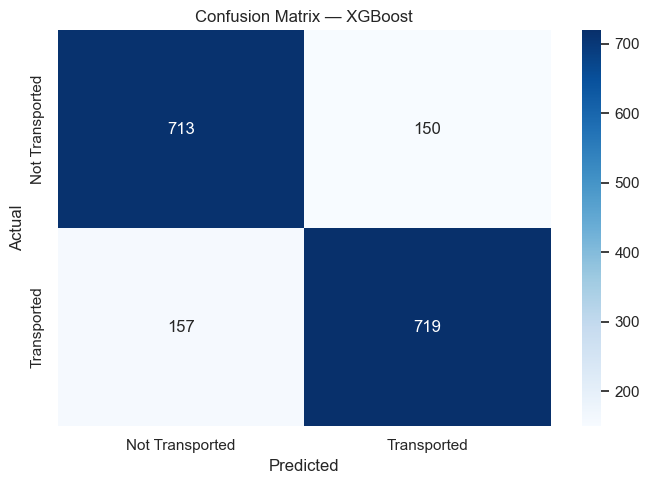

In [23]:
best_model_name = results_df['Validation Accuracy'].idxmax()
print(f'Mô hình tốt nhất trên Validation: {best_model_name}')

all_models = {**baseline_models, **bagging_models, **boosting_models,
              'Stacking': stacking_model, 'Soft Voting': voting_model}
best_single_model = all_models[best_model_name]

y_val_pred = best_single_model.predict(X_val)

print('\n--- Classification Report ---')
print(classification_report(y_val, y_val_pred, target_names=['Not Transported', 'Transported']))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

## Đánh giá chi tiết mô hình tốt nhất

Hiển thị **Classification Report** (Precision, Recall, F1-score) và **Confusion Matrix** cho mô hình có Validation Accuracy cao nhất.

- **Precision**: Trong các mẫu được dự đoán là Transported, bao nhiêu % thực sự đúng.
- **Recall**: Trong tất cả mẫu thực sự Transported, bao nhiêu % được nhận diện đúng.
- **F1-score**: Trung bình điều hòa giữa Precision và Recall.

In [24]:
final_stacking = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)),
        ('et', ExtraTreesClassifier(n_estimators=500, max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(
            n_estimators=500, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, n_jobs=-1
        )),
        ('lgbm', LGBMClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbose=-1
        )),
        ('cat', CatBoostClassifier(
            iterations=500, depth=6, learning_rate=0.05,
            random_state=42, verbose=0
        )),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print('Đang huấn luyện Stacking trên toàn bộ training data...')
final_stacking.fit(X, y)
print('Hoàn tất!')

test_preds = final_stacking.predict(X_test_final)
test_preds_bool = test_preds.astype(bool)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_preds_bool
})

submission.to_csv('submission.csv', index=False)
print(f'\nSubmission saved! Shape: {submission.shape}')
print(submission.head(10))
print(f'\nTransported distribution:\n{submission["Transported"].value_counts()}')

Đang huấn luyện Stacking trên toàn bộ training data...
Hoàn tất!

Submission saved! Shape: (4277, 2)
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01        False
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01         True

Transported distribution:
Transported
True     2268
False    2009
Name: count, dtype: int64


## Tạo file Submission

1. **Retrain trên toàn bộ training data**: Huấn luyện lại mô hình Stacking (mô hình mạnh nhất) trên toàn bộ `X` (không giữ validation) để tận dụng tối đa dữ liệu.
2. **Dự đoán trên tập test**: Sinh dự đoán `True/False` cho mỗi hành khách.
3. **Lưu file `submission.csv`**: Đúng format yêu cầu của Kaggle (`PassengerId`, `Transported`).

File này có thể nộp trực tiếp lên [Kaggle Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic/submit) để xem score trên leaderboard.

In [25]:
print('--- Kiểm tra file submission ---')
sub_check = pd.read_csv('submission.csv')
sample = pd.read_csv('sample_submission.csv')

print(f'Submission shape: {sub_check.shape} (expected: {sample.shape})')
print(f'Columns match: {list(sub_check.columns) == list(sample.columns)}')
print(f'PassengerId match: {list(sub_check["PassengerId"]) == list(sample["PassengerId"])}')
print(f'Transported dtype: {sub_check["Transported"].dtype}')
print(f'Unique values: {sub_check["Transported"].unique()}')
print('\n File submission hợp lệ!' if sub_check.shape == sample.shape else '\n Có lỗi!')

--- Kiểm tra file submission ---
Submission shape: (4277, 2) (expected: (4277, 2))
Columns match: True
PassengerId match: True
Transported dtype: bool
Unique values: [ True False]

 File submission hợp lệ!


## Kiểm tra file Submission

Xác nhận file `submission.csv`:
- Đúng số lượng dòng (bằng `sample_submission.csv`)
- Đúng tên cột (`PassengerId`, `Transported`)
- Giá trị `Transported` là `True/False`

---

## Tổng kết

### Các kỹ thuật Ensemble Learning đã sử dụng:

| Kỹ thuật | Mô hình | Nguyên lý |
|---|---|---|
| **Bagging** | Random Forest, Extra Trees, BaggingClassifier | Giảm variance bằng bootstrap sampling + aggregation |
| **Boosting** | AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost | Giảm bias bằng huấn luyện tuần tự, mỗi mô hình sửa lỗi mô hình trước |
| **Stacking** | StackingClassifier (5 base + LR meta) | Kết hợp đa dạng mô hình qua meta-learner |
| **Voting** | VotingClassifier (soft) | Trung bình xác suất dự đoán |

### Kết quả:
- Các mô hình Ensemble đều cho kết quả vượt trội so với mô hình đơn lẻ (LR, DT).
- **Boosting** (XGBoost, LightGBM, CatBoost) và **Stacking** thường cho kết quả tốt nhất.
- File `submission.csv` đã được tạo sẵn để nộp lên Kaggle.

---
*Bài tập buổi 11 — Ensemble Learning — Hoàn thành!*